#  South Africa Load Shedding & Energy Analysis
**Author:** Luxolo Luvalo  
**Dataset Sources:** Kaggle — EskomSePush History, ESK2033 Eskom Grid Data, SA Load Shedding History  
**Goal:** Analyze load shedding patterns and electricity generation trends in South Africa

---

##**Step 1: Install & Import Libraries**

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# Set a clean visual style
sns.set_theme(style='darkgrid', palette='muted')
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 12

print(' Libraries loaded successfully!')

 Libraries loaded successfully!


##  Step 2: Upload Your Datasets
Run the cell below and upload these files when prompted:
- `south_africa_load_shedding_history.csv`
- `EskomSePush_history.csv`
- `ESK2033.csv`
- `Total_Electricity_Production.csv`

In [17]:
from google.colab import files
uploaded = files.upload()
print(' Files uploaded:', list(uploaded.keys()))

 Files uploaded: []


##  Step 3: Load & Explore the Data

In [18]:
# Load all datasets
shedding_old = pd.read_csv('south_africa_load_shedding_history.csv')
shedding_new = pd.read_csv('EskomSePush_history.csv')
eskom_grid   = pd.read_csv('ESK2033.csv')
electricity  = pd.read_csv('Total_Electricity_Production.csv')

print('=== Dataset Shapes ===')
print(f'SA Load Shedding History : {shedding_old.shape}')
print(f'EskomSePush History      : {shedding_new.shape}')
print(f'Eskom Grid Data (ESK2033): {eskom_grid.shape}')
print(f'Total Electricity Prod   : {electricity.shape}')

=== Dataset Shapes ===
SA Load Shedding History : (422, 2)
EskomSePush History      : (670, 2)
Eskom Grid Data (ESK2033): (43824, 42)
Total Electricity Prod   : (135, 2)


In [19]:
# Preview each dataset
print('--- Load Shedding History (old) ---')
display(shedding_old.head())

print('\n--- EskomSePush History (new) ---')
display(shedding_new.head())

print('\n--- Eskom Grid Data ---')
display(eskom_grid.head())

print('\n--- Total Electricity Production ---')
display(electricity.head())

--- Load Shedding History (old) ---


,created_at,stage
0,9/7/2020 20:03:18,0
1,9/7/2020 14:00:22,2
2,9/7/2020 6:00:53,1
3,9/6/2020 18:16:14,0
4,9/6/2020 10:00:25,1



--- EskomSePush History (new) ---


,created_at,stage
0,2022-08-18 23:42:45,0
1,2022-08-18 16:00:29,2
2,2022-08-18 0:02:50,0
3,2022-08-17 16:00:41,2
4,2022-08-17 0:02:36,0



--- Eskom Grid Data ---


,Date Time Hour Beginning,Original Res Forecast before Lockdown,Residual Forecast,RSA Contracted Forecast,Dispatchable Generation,Residual Demand,RSA Contracted Demand,International Exports,International Imports,Thermal Generation,...,Total RE Installed Capacity,Installed Eskom Capacity,Total PCLF,Total UCLF,Total OCLF,Total UCLF+OCLF,Non Comm Sentout,Drakensberg Gen Unit Hours,Palmiet Gen Unit Hours,Ingula Gen Unit Hours
2018-04-01 12:00:00 AM,NaN,19904.967,20367.066,20237.0,20237.0,20722.058,1215.902,1120.0,19444.0,931.0,...,44546.0,3987.472,8028.710,275.907,8304.0,617.0,383.0,81.8,36.9,30.41
2018-04-01 01:00:00 AM,NaN,19553.899,19988.733,19744.0,19744.0,20188.493,1203.474,1106.0,19297.0,930.0,...,44546.0,3987.472,7727.302,244.907,7972.0,209.0,388.0,83.0,38.5,32.85
2018-04-01 02:00:00 AM,NaN,19314.284,19731.239,19631.0,19631.0,20019.603,1177.571,1117.0,19165.0,931.0,...,44546.0,3987.472,7704.704,193.727,7898.0,431.0,388.0,83.8,40.3,35.60
2018-04-01 03:00:00 AM,NaN,19342.679,19753.554,19731.0,19731.0,20079.454,1184.312,1118.0,19279.0,930.0,...,44546.0,3990.072,7702.868,187.000,7889.0,868.0,389.0,85.0,42.0,37.76
2018-04-01 04:00:00 AM,NaN,19538.890,19988.365,19890.0,19890.0,20237.490,1197.271,1108.0,19369.0,930.0,...,44546.0,3990.472,7685.115,187.000,7872.0,115.0,385.0,85.8,43.7,40.32



--- Total Electricity Production ---


,DATE,PRENEL01ZAQ656N
0,1985-01-01,11072.666667
1,1985-04-01,11879.666667
2,1985-07-01,12485.333333
3,1985-10-01,11690.333333
4,1986-01-01,11374.000000


##  Step 4: Clean the Data

In [20]:
# --- Clean Load Shedding datasets ---
shedding_old['created_at'] = pd.to_datetime(shedding_old['created_at'])
shedding_new['created_at'] = pd.to_datetime(shedding_new['created_at'])

# Combine both shedding datasets
shedding_all = pd.concat([shedding_old, shedding_new], ignore_index=True)
shedding_all = shedding_all.sort_values('created_at').reset_index(drop=True)

# Extract time features
shedding_all['date']  = shedding_all['created_at'].dt.date
shedding_all['year']  = shedding_all['created_at'].dt.year
shedding_all['month'] = shedding_all['created_at'].dt.month
shedding_all['hour']  = shedding_all['created_at'].dt.hour
shedding_all['day_of_week'] = shedding_all['created_at'].dt.day_name()

print(f' Combined shedding records: {len(shedding_all)}')
print(f'   Date range: {shedding_all["created_at"].min()} → {shedding_all["created_at"].max()}')
print(f'   Stages found: {sorted(shedding_all["stage"].unique())}')

 Combined shedding records: 1092
   Date range: 2015-01-09 11:47:19 → 2022-08-18 23:42:45
   Stages found: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6)]


In [21]:
# --- Clean Eskom Grid Data ---
eskom_grid['Date Time Hour Beginning'] = pd.to_datetime(eskom_grid['Date Time Hour Beginning'])
eskom_grid['year']  = eskom_grid['Date Time Hour Beginning'].dt.year
eskom_grid['month'] = eskom_grid['Date Time Hour Beginning'].dt.month
eskom_grid['hour']  = eskom_grid['Date Time Hour Beginning'].dt.hour

# Check for nulls
print('Null values in key columns:')
print(eskom_grid[['Thermal Generation','Nuclear Generation','Wind','PV','Total UCLF']].isnull().sum())

# --- Clean Electricity Production ---
electricity['DATE'] = pd.to_datetime(electricity['DATE'])
electricity.columns = ['date', 'production_gwh']
electricity['year'] = electricity['date'].dt.year

print('\n Grid and electricity data cleaned!')

Null values in key columns:
Thermal Generation    6120
Nuclear Generation    6120
Wind                  6120
PV                    6120
Total UCLF            6120
dtype: int64

 Grid and electricity data cleaned!


##  Step 5: Analysis & Visualizations

### Chart 1 — Load Shedding Stage Distribution

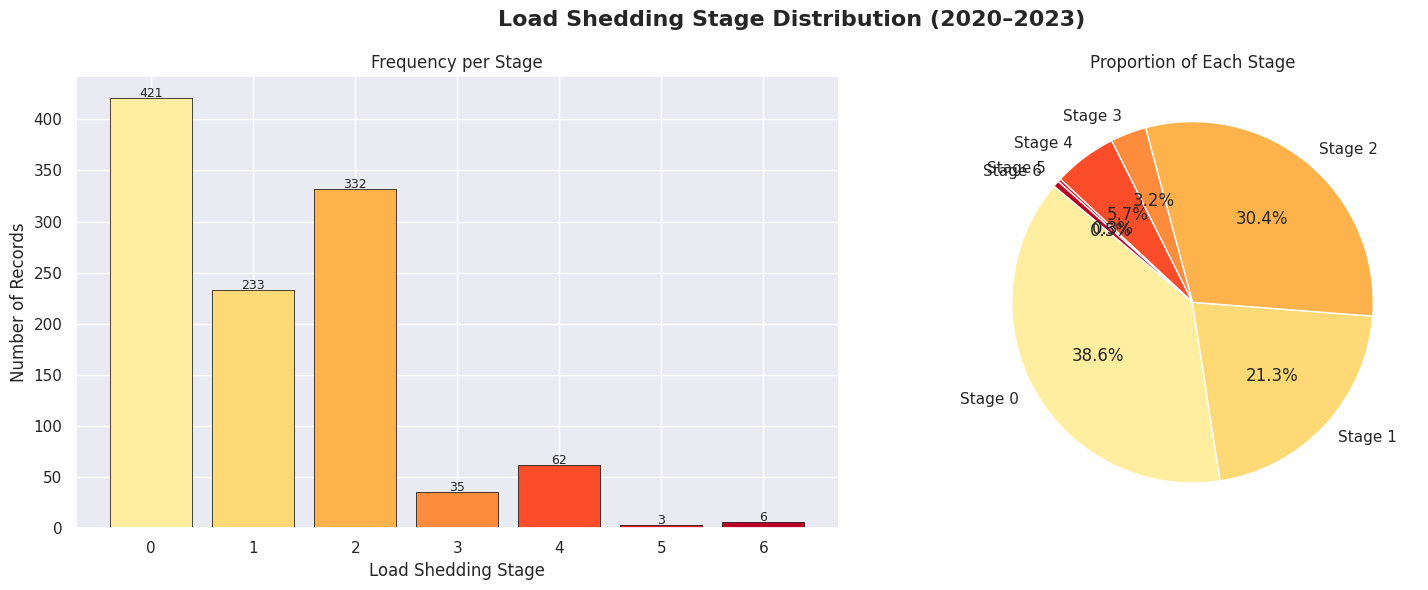

 Chart 1 saved.


In [22]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Load Shedding Stage Distribution (2020–2023)', fontsize=16, fontweight='bold')

stage_counts = shedding_all['stage'].value_counts().sort_index()
colors = sns.color_palette('YlOrRd', len(stage_counts))

# Bar chart
axes[0].bar(stage_counts.index.astype(str), stage_counts.values, color=colors, edgecolor='black', linewidth=0.5)
axes[0].set_xlabel('Load Shedding Stage')
axes[0].set_ylabel('Number of Records')
axes[0].set_title('Frequency per Stage')
for i, (x, y) in enumerate(zip(stage_counts.index, stage_counts.values)):
    axes[0].text(i, y + 1, str(y), ha='center', fontsize=9)

# Pie chart
axes[1].pie(stage_counts.values, labels=[f'Stage {s}' for s in stage_counts.index],
            colors=colors, autopct='%1.1f%%', startangle=140)
axes[1].set_title('Proportion of Each Stage')

plt.tight_layout()
plt.savefig('chart1_stage_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print(' Chart 1 saved.')

### Chart 2 — Load Shedding Over Time (Monthly Average Stage)

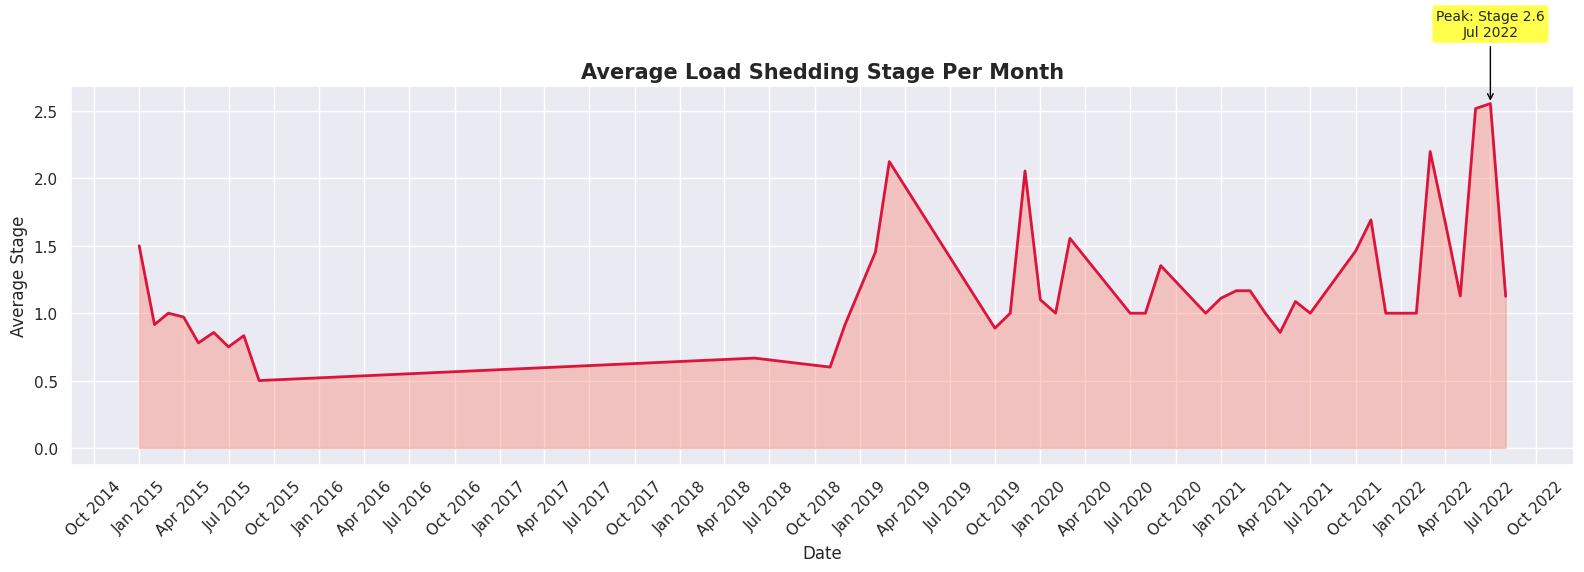

✅ Chart 2 saved.


In [23]:
monthly_avg = shedding_all.groupby(shedding_all['created_at'].dt.to_period('M'))['stage'].mean().reset_index()
monthly_avg['created_at'] = monthly_avg['created_at'].dt.to_timestamp()

fig, ax = plt.subplots(figsize=(16, 6))
ax.fill_between(monthly_avg['created_at'], monthly_avg['stage'], alpha=0.3, color='tomato')
ax.plot(monthly_avg['created_at'], monthly_avg['stage'], color='crimson', linewidth=2)
ax.set_title('Average Load Shedding Stage Per Month', fontsize=15, fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Average Stage')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
plt.xticks(rotation=45)

# Annotate peak
peak_idx = monthly_avg['stage'].idxmax()
peak_date = monthly_avg.loc[peak_idx, 'created_at']
peak_val  = monthly_avg.loc[peak_idx, 'stage']
ax.annotate(f'Peak: Stage {peak_val:.1f}\n{peak_date.strftime("%b %Y")}',
            xy=(peak_date, peak_val), xytext=(peak_date, peak_val + 0.5),
            arrowprops=dict(arrowstyle='->', color='black'),
            fontsize=10, ha='center',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='yellow', alpha=0.7))

plt.tight_layout()
plt.savefig('chart2_monthly_trend.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Chart 2 saved.')

### Chart 3 — Load Shedding by Hour of Day (When Does It Hit Most?)

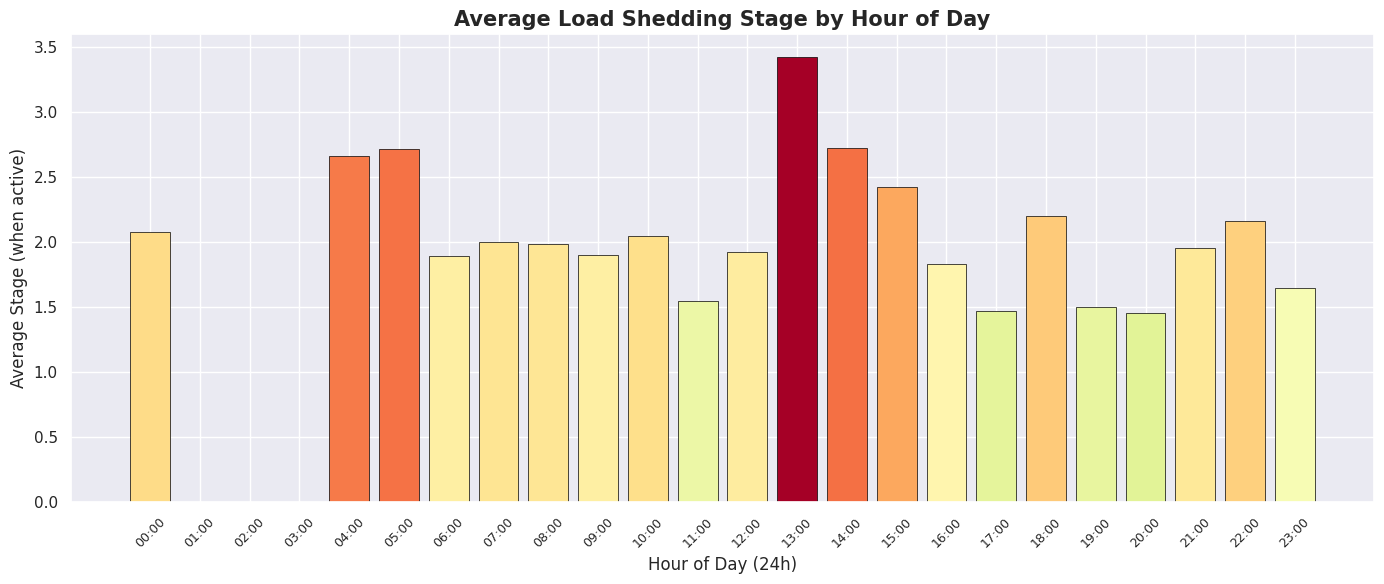

 Chart 3 saved.


In [24]:
# Only look at active shedding (stage > 0)
active = shedding_all[shedding_all['stage'] > 0]
hourly = active.groupby('hour')['stage'].mean()

fig, ax = plt.subplots(figsize=(14, 6))
bars = ax.bar(hourly.index, hourly.values,
              color=plt.cm.RdYlGn_r(hourly.values / hourly.max()),
              edgecolor='black', linewidth=0.5)
ax.set_title('Average Load Shedding Stage by Hour of Day', fontsize=15, fontweight='bold')
ax.set_xlabel('Hour of Day (24h)')
ax.set_ylabel('Average Stage (when active)')
ax.set_xticks(range(0, 24))
ax.set_xticklabels([f'{h:02d}:00' for h in range(24)], rotation=45, fontsize=9)

plt.tight_layout()
plt.savefig('chart3_hourly_pattern.png', dpi=150, bbox_inches='tight')
plt.show()
print(' Chart 3 saved.')

### Chart 4 — Eskom Generation Mix: Where Does SA's Power Come From?

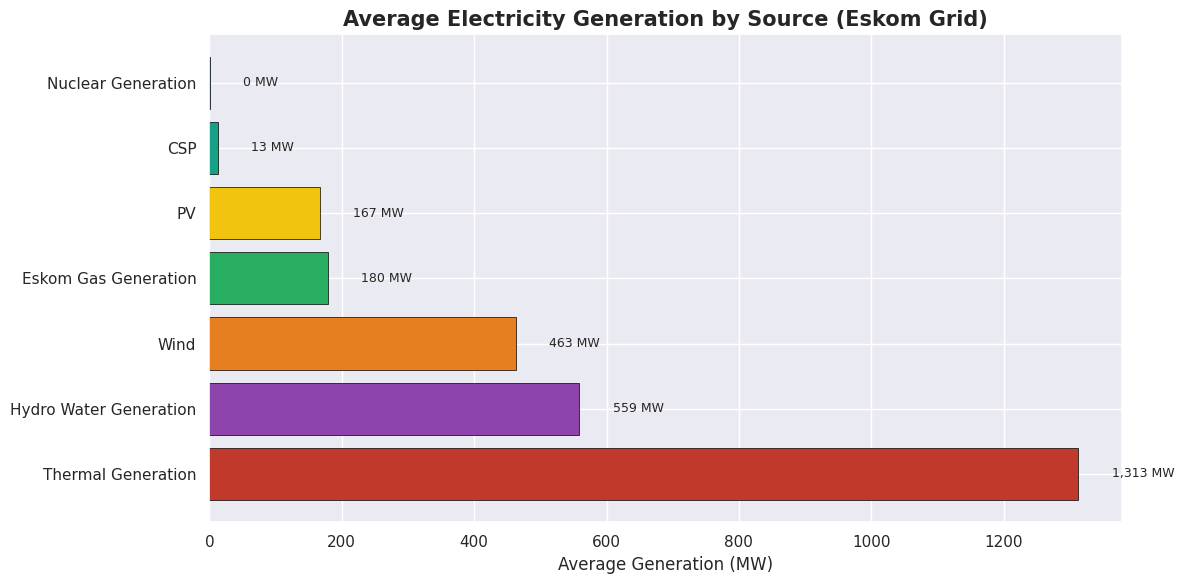

 Chart 4 saved.


In [25]:
gen_cols = ['Thermal Generation', 'Nuclear Generation',
            'Eskom Gas Generation', 'Wind', 'PV', 'CSP', 'Hydro Water Generation']

gen_means = eskom_grid[gen_cols].mean().sort_values(ascending=False)
colors = ['#c0392b','#8e44ad','#e67e22','#27ae60','#f1c40f','#16a085','#2980b9']

fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.barh(gen_means.index, gen_means.values, color=colors, edgecolor='black', linewidth=0.5)
ax.set_title("Average Electricity Generation by Source (Eskom Grid)", fontsize=15, fontweight='bold')
ax.set_xlabel('Average Generation (MW)')
for bar, val in zip(bars, gen_means.values):
    ax.text(val + 50, bar.get_y() + bar.get_height()/2,
            f'{val:,.0f} MW', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('chart4_generation_mix.png', dpi=150, bbox_inches='tight')
plt.show()
print(' Chart 4 saved.')

### Chart 5 — Unplanned Outages (UCLF) vs Load Shedding Intensity Over Time

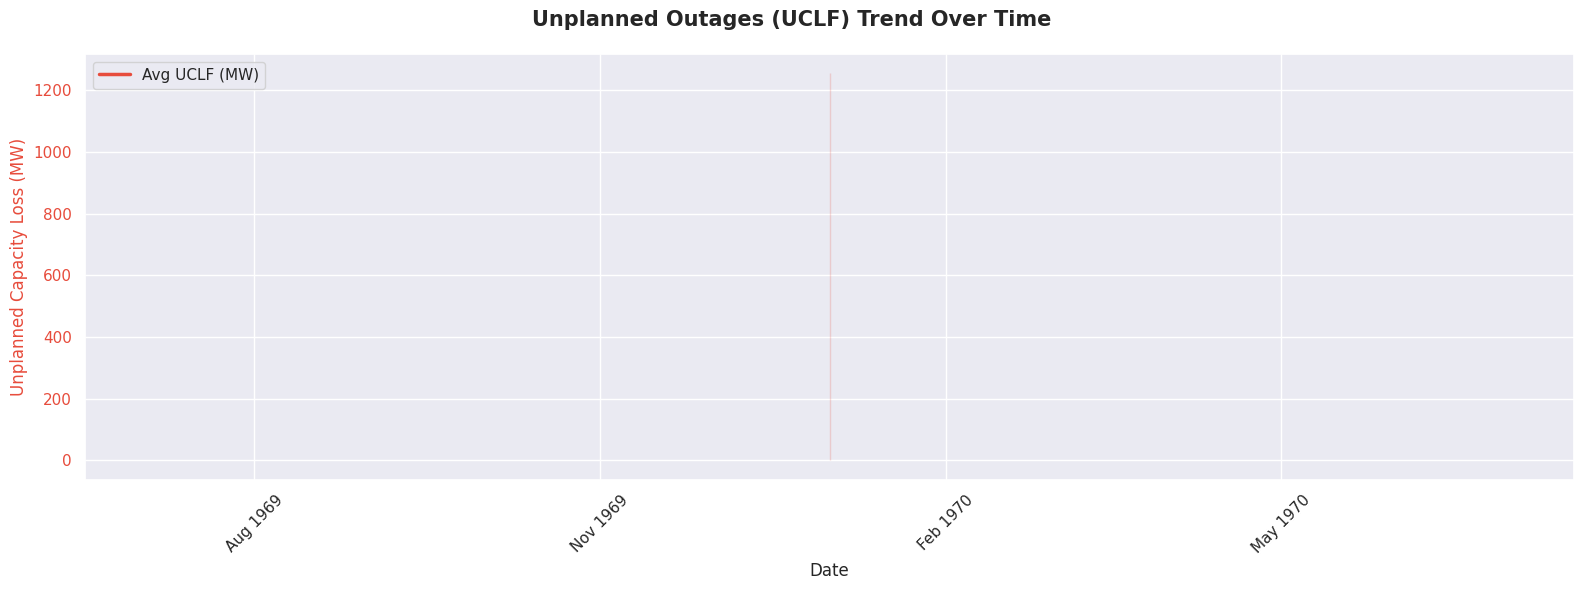

 Chart 5 saved.


In [26]:
# Monthly average UCLF (Unplanned Capacity Loss Factor)
eskom_grid['month_period'] = eskom_grid['Date Time Hour Beginning'].dt.to_period('M')
monthly_uclf = eskom_grid.groupby('month_period')['Total UCLF'].mean().reset_index()
monthly_uclf['month_period'] = monthly_uclf['month_period'].dt.to_timestamp()

fig, ax1 = plt.subplots(figsize=(16, 6))
fig.suptitle('Unplanned Outages (UCLF) Trend Over Time', fontsize=15, fontweight='bold')

color1 = '#e74c3c'
ax1.plot(monthly_uclf['month_period'], monthly_uclf['Total UCLF'], color=color1, linewidth=2.5, label='Avg UCLF (MW)')
ax1.fill_between(monthly_uclf['month_period'], monthly_uclf['Total UCLF'], alpha=0.2, color=color1)
ax1.set_xlabel('Date')
ax1.set_ylabel('Unplanned Capacity Loss (MW)', color=color1)
ax1.tick_params(axis='y', labelcolor=color1)
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax1.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
plt.xticks(rotation=45)

ax1.legend(loc='upper left')
plt.tight_layout()
plt.savefig('chart5_uclf_trend.png', dpi=150, bbox_inches='tight')
plt.show()
print(' Chart 5 saved.')

### Chart 6 — Renewable Energy Growth (Wind + Solar Over Time)

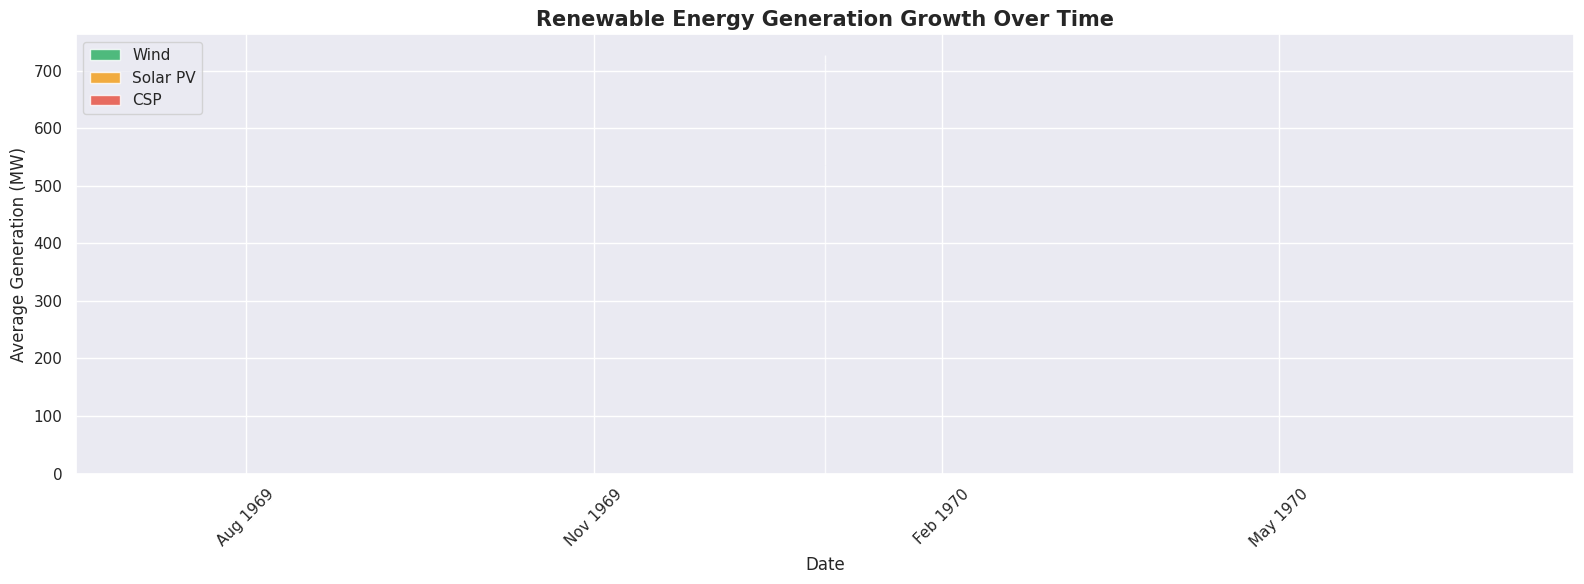

Chart 6 saved.


In [27]:
monthly_re = eskom_grid.groupby('month_period')[['Wind', 'PV', 'CSP']].mean().reset_index()
monthly_re['month_period'] = monthly_re['month_period'].dt.to_timestamp()

fig, ax = plt.subplots(figsize=(16, 6))
ax.stackplot(monthly_re['month_period'],
             monthly_re['Wind'], monthly_re['PV'], monthly_re['CSP'],
             labels=['Wind', 'Solar PV', 'CSP'],
             colors=['#27ae60', '#f39c12', '#e74c3c'], alpha=0.8)
ax.set_title('Renewable Energy Generation Growth Over Time', fontsize=15, fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Average Generation (MW)')
ax.legend(loc='upper left')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
plt.xticks(rotation=45)

plt.tight_layout()
plt.savefig('chart6_renewable_growth.png', dpi=150, bbox_inches='tight')
plt.show()
print('Chart 6 saved.')

### Chart 7 — Long-Term Electricity Production Trend (1985–Present)

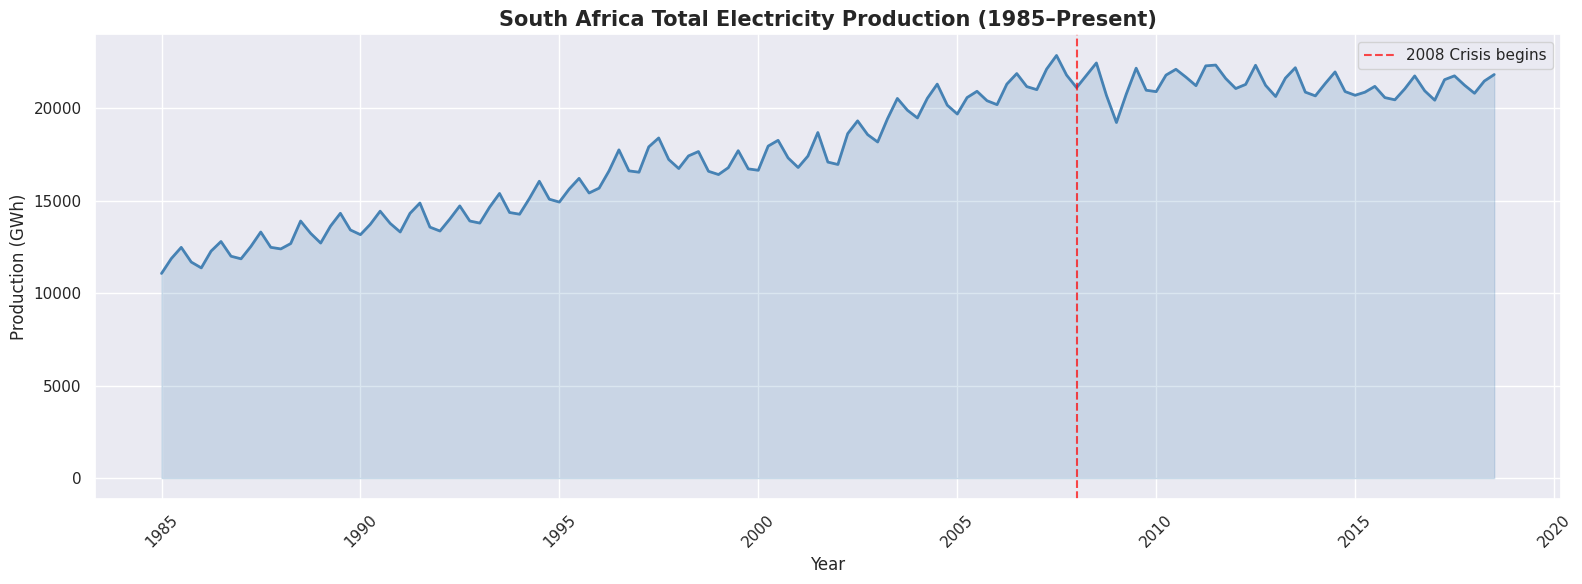

 Chart 7 saved.


In [28]:
fig, ax = plt.subplots(figsize=(16, 6))
ax.plot(electricity['date'], electricity['production_gwh'], color='steelblue', linewidth=2)
ax.fill_between(electricity['date'], electricity['production_gwh'], alpha=0.2, color='steelblue')
ax.set_title('South Africa Total Electricity Production (1985–Present)', fontsize=15, fontweight='bold')
ax.set_xlabel('Year')
ax.set_ylabel('Production (GWh)')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.xaxis.set_major_locator(mdates.YearLocator(5))
plt.xticks(rotation=45)

# Mark the post-2008 decline
ax.axvline(pd.Timestamp('2008-01-01'), color='red', linestyle='--', alpha=0.7, label='2008 Crisis begins')
ax.legend()

plt.tight_layout()
plt.savefig('chart7_longterm_production.png', dpi=150, bbox_inches='tight')
plt.show()
print(' Chart 7 saved.')

## 📈 Step 6: Key Statistics Summary

In [29]:
print('=' * 55)
print('   SOUTH AFRICA LOAD SHEDDING — KEY FINDINGS')
print('=' * 55)

total_records = len(shedding_all)
active_records = len(shedding_all[shedding_all['stage'] > 0])
pct_active = (active_records / total_records) * 100
max_stage = shedding_all['stage'].max()
avg_stage_active = shedding_all[shedding_all['stage'] > 0]['stage'].mean()

date_min = shedding_all['created_at'].min().strftime('%d %b %Y')
date_max = shedding_all['created_at'].max().strftime('%d %b %Y')

print(f'\n Date Range          : {date_min} → {date_max}')
print(f' Total Records       : {total_records:,}')
print(f' Active Shedding     : {active_records:,} ({pct_active:.1f}% of time)')
print(f' Highest Stage       : Stage {max_stage}')
print(f' Avg Stage (active)  : {avg_stage_active:.2f}')

peak_year = shedding_all[shedding_all['stage'] > 0].groupby('year')['stage'].mean().idxmax()
print(f' Worst Year          : {peak_year}')

print(f'\n Renewable Energy (latest avg):')
for src in ['Wind', 'PV', 'CSP']:
    latest = eskom_grid.tail(24*30)[src].mean()
    print(f'   {src:8s}: {latest:,.0f} MW avg')

print('\n' + '=' * 55)

   SOUTH AFRICA LOAD SHEDDING — KEY FINDINGS

 Date Range          : 09 Jan 2015 → 18 Aug 2022
 Total Records       : 1,092
 Active Shedding     : 671 (61.4% of time)
 Highest Stage       : Stage 6
 Avg Stage (active)  : 1.94
 Worst Year          : 2022

 Renewable Energy (latest avg):
   Wind    : nan MW avg
   PV      : nan MW avg
   CSP     : nan MW avg



## 💾 Step 7: Download Your Charts

In [30]:
from google.colab import files
import os

charts = [
    'chart1_stage_distribution.png',
    'chart2_monthly_trend.png',
    'chart3_hourly_pattern.png',
    'chart4_generation_mix.png',
    'chart5_uclf_trend.png',
    'chart6_renewable_growth.png',
    'chart7_longterm_production.png'
]

for chart in charts:
    if os.path.exists(chart):
        files.download(chart)
        print(f'⬇  Downloaded: {chart}')
    else:
        print(f'⚠️  Not found: {chart} — make sure you ran that cell')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

⬇  Downloaded: chart1_stage_distribution.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

⬇  Downloaded: chart6_renewable_growth.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

⬇  Downloaded: chart7_longterm_production.png
